In [1]:
from google.colab import files
uploaded = files.upload()

Saving Outcomes-a.txt to Outcomes-a (1).txt


In [2]:
import pandas as pd

df = pd.read_csv("Outcomes-a.txt")
df.head()

,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [4]:
X = df.drop("In-hospital_death", axis=1)
y = df["In-hospital_death"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
X_train.isnull().sum()

,0
RecordID,0
SAPS-I,0
SOFA,0
Length_of_stay,0
Survival,0


In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [11]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       679
           1       1.00      0.02      0.03       121

    accuracy                           0.85       800
   macro avg       0.93      0.51      0.48       800
weighted avg       0.87      0.85      0.79       800

Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       679
           1       0.91      0.98      0.94       121

    accuracy                           0.98       800
   macro avg       0.95      0.98      0.97       800
weighted avg       0.98      0.98      0.98       800



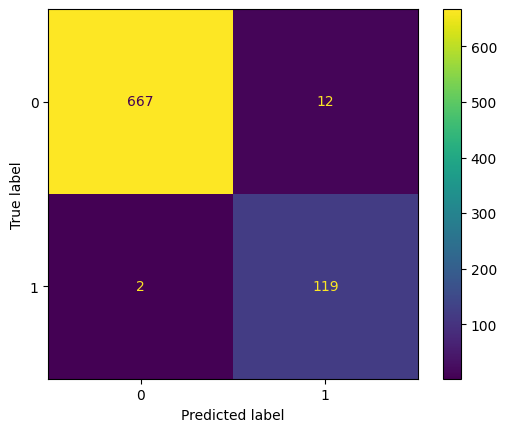

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

In [13]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob)

np.float64(0.9980768996701517)

In [14]:
!pip install shap

In [19]:
import pandas as pd

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [20]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [22]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_test.shape)

<class 'numpy.ndarray'>
800
(5, 2)
(800, 5)


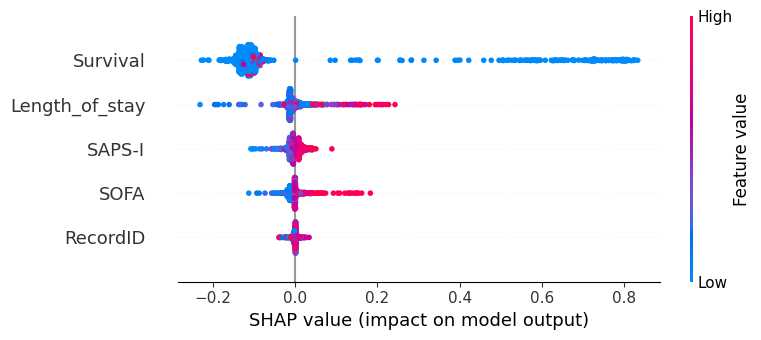

In [27]:
import shap
import numpy as np
import pandas as pd

# Make sure X_test is a DataFrame with column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

# Handle both old and new SHAP output formats
if isinstance(shap_values, list):
    # old format: one array per class
    shap_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # new format: (samples, features, classes)
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns)